In [1]:
import os
import numpy as np
import pandas as pd 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        
        print(os.path.join(dirname, filename))


import kagglehub

/kaggle/input/datasets/adityammantri/trial-1/preprocessed_unlabelled_data_bert.xlsx
/kaggle/input/datasets/adityammantri/trial-1/processed_labeled_dataset_without_encoding.xlsx


In [2]:
df=pd.read_excel("/kaggle/input/datasets/adityammantri/trial-1/processed_labeled_dataset_without_encoding.xlsx")
print(df.head())
print(df.tail())

                                   job_title  location  industry  \
0                        mental health nurse      4688       649   
1                  conference centre manager      1524       512   
2                              engineer land      1520       649   
3                     forestwoodland manager      1899       435   
4  production designer theatretelevisionfilm       431      1078   

   salary_range                                company_profile  \
0  55016-100476              rivera and sons  established 2022   
1   53438-93138     davidson jones and gomez  established 2003   
2  45584-105229                    allen ltd  established 1998   
3  66188-139621                   forbes ltd  established 1990   
4  32183-115012  jennings martin and sanchez  established 1975   

                                            job_desc  \
0  arm drive court sure vote earn 5000week immedi...   
1  government whom its bed go tax tree black earn...   
2  i member discuss follow

In [3]:
print(df.info())
print(df.isnull().sum())
df = df.dropna(subset=["fraudulent"])
print(df.shape)
df = df.drop(columns=["salary_range"])
df["company_profile"] = df["company_profile"].fillna("")
df["job_desc"] = df["job_desc"].fillna("")
df["skills_desc"] = df["skills_desc"].fillna("")
df["employment_type"] = df["employment_type"].fillna("Unknown")
df["job_title"] = df["job_title"].fillna("Unknown")
print(df.isnull().sum())
df["fraudulent"] = df["fraudulent"].astype(int)
df["fraudulent"].value_counts()
df["fraudulent"].value_counts(normalize=True) * 100



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54391 entries, 0 to 54390
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_title        54389 non-null  object 
 1   location         54391 non-null  int64  
 2   industry         54391 non-null  int64  
 3   salary_range     17123 non-null  object 
 4   company_profile  45992 non-null  object 
 5   job_desc         50871 non-null  object 
 6   skills_desc      41522 non-null  object 
 7   employment_type  38823 non-null  object 
 8   fraudulent       44045 non-null  float64
 9   text             54391 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 4.1+ MB
None
job_title              2
location               0
industry               0
salary_range       37268
company_profile     8399
job_desc            3520
skills_desc        12869
employment_type    15568
fraudulent         10346
text                   0
dtype: int64
(44045, 1

fraudulent
0    71.567715
1    28.432285
Name: proportion, dtype: float64

In [4]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_top_words(text_series, n=20):
    words = " ".join(text_series).split()

    words = [
        word for word in words
        if word.isalpha()
        and len(word) > 1          # Remove single letters
        and word not in ENGLISH_STOP_WORDS
    ]

    return Counter(words).most_common(n)


In [5]:
df["text"] = (
    df["text"]
    .str.replace("ã", " ", regex=False)
    .str.replace("â", " ", regex=False)
    .str.replace("€", " ", regex=False)
)
df["text"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()

In [6]:
import re

df["text"] = df["text"].str.lower()

df["text"] = df["text"].apply(lambda x: re.sub(r"[^a-z\s]", " ", x))

df["text"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()

In [7]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")
nltk.download("omw-1.4")
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


In [8]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove non-letter characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stop words and lemmatize
    words = [
        lemmatizer.lemmatize(word) 
        for word in words
        if word not in ENGLISH_STOP_WORDS
    ]

    return " ".join(words)

# Apply preprocessing to create a new column
df["clean_text"] = df["text"].apply(preprocess_text)

In [9]:
def preprocess_text(text):
    text = text.lower()

    # Expand common contractions BEFORE removing punctuation
    text = text.replace("'s", "")
    text = text.replace("'re", " are")
    text = text.replace("'ve", " have")
    text = text.replace("'ll", " will")
    text = text.replace("'d", " would")
    text = text.replace("n't", " not")

    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    # Remove stop words and unwanted short tokens
    remove_words = {
        "s", "t", "re", "ve", "ll", "d", "m",
        "uk", "usa"
    }

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in ENGLISH_STOP_WORDS
        and word not in remove_words
        and len(word) > 1
    ]

    return " ".join(words)

In [10]:
df["clean_text"] = df["text"].apply(preprocess_text)
df_model = df.drop_duplicates(subset=["clean_text"]).copy()

print(df.shape)
print(df_model.shape)

(44045, 10)
(26003, 10)


In [11]:
print(df.shape)
df.dtypes
df.describe(include="all")

(44045, 10)


,job_title,location,industry,company_profile,job_desc,skills_desc,employment_type,fraudulent,text,clean_text
count,44045,44045.000000,44045.000000,44045,44045,44045,44045,44045.000000,44045,44045
unique,11253,NaN,NaN,11710,24918,13177,12,NaN,26021,26003
top,customer service associate,NaN,NaN,,play with kids get paid for itã love travel jo...,,Full-time,NaN,english teacher abroad we help teachers get sa...,english teacher abroad help teacher safe amp s...
freq,424,NaN,NaN,6947,379,4605,23564,NaN,401,401
mean,NaN,2180.054808,822.538858,NaN,NaN,NaN,NaN,0.284323,NaN,NaN
std,NaN,1331.881690,419.193500,NaN,NaN,NaN,NaN,0.451096,NaN,NaN
min,NaN,0.000000,2.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,1166.000000,512.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,NaN,1954.000000,704.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,NaN,3223.000000,1263.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


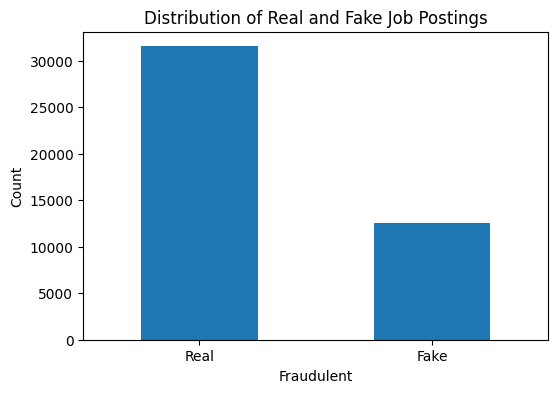

In [12]:
import matplotlib.pyplot as plt

df["fraudulent"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribution of Real and Fake Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Count")
plt.xticks([0,1],["Real","Fake"],rotation=0)

plt.show()

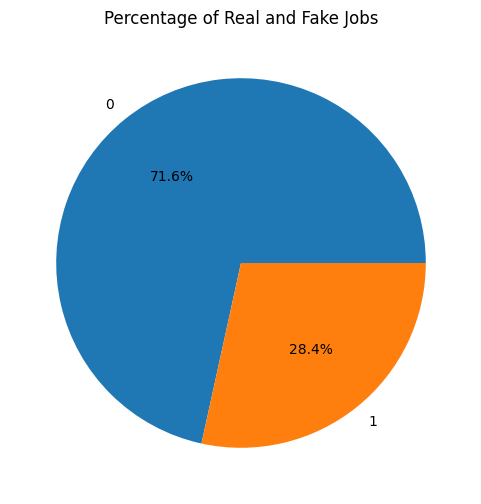

In [13]:
df["fraudulent"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Percentage of Real and Fake Jobs")

plt.show()

In [14]:
print(df["employment_type"].unique())
print(df["employment_type"].value_counts())
df["employment_type"] = (
    df["employment_type"]
    .str.strip()          
    .str.title()          
)
df["employment_type"] = df["employment_type"].replace({
    "Full-Time": "Full Time",
    "Part-Time": "Part Time",
    "Fulltime": "Full Time",
    "Parttime": "Part Time",
    "Internship & Graduate": "Internship"
})
print(df["employment_type"].unique())

['Internship' 'Part-Time' 'Full-Time' 'Temporary' 'Contract' 'Other'
 'Full-time' 'Unknown' 'Part-time' 'Full Time' 'Internship & Graduate'
 'Part Time']
employment_type
Full-time                23564
Unknown                   5222
Contract                  4501
Temporary                 2486
Part-Time                 2039
Internship                1982
Full-Time                 1977
Part-time                 1667
Other                      463
Full Time                  140
Part Time                    3
Internship & Graduate        1
Name: count, dtype: int64
['Internship' 'Part Time' 'Full Time' 'Temporary' 'Contract' 'Other'
 'Unknown']


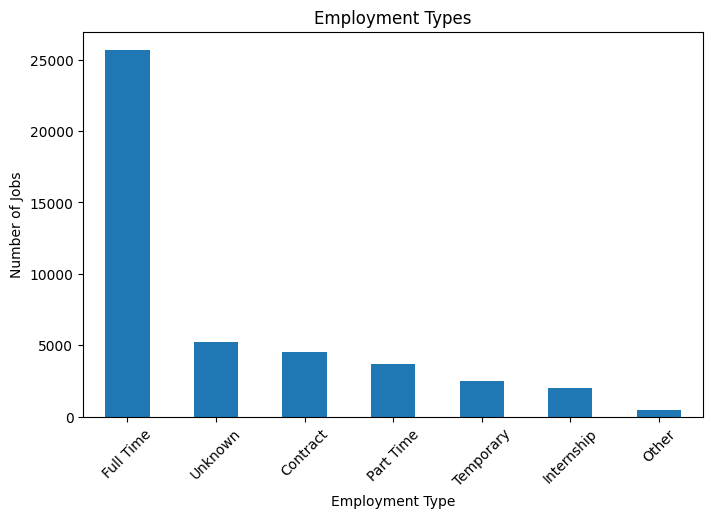

In [15]:
plt.figure(figsize=(8,5))

df["employment_type"].value_counts().plot(kind="bar")

plt.title("Employment Types")
plt.xlabel("Employment Type")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.show()

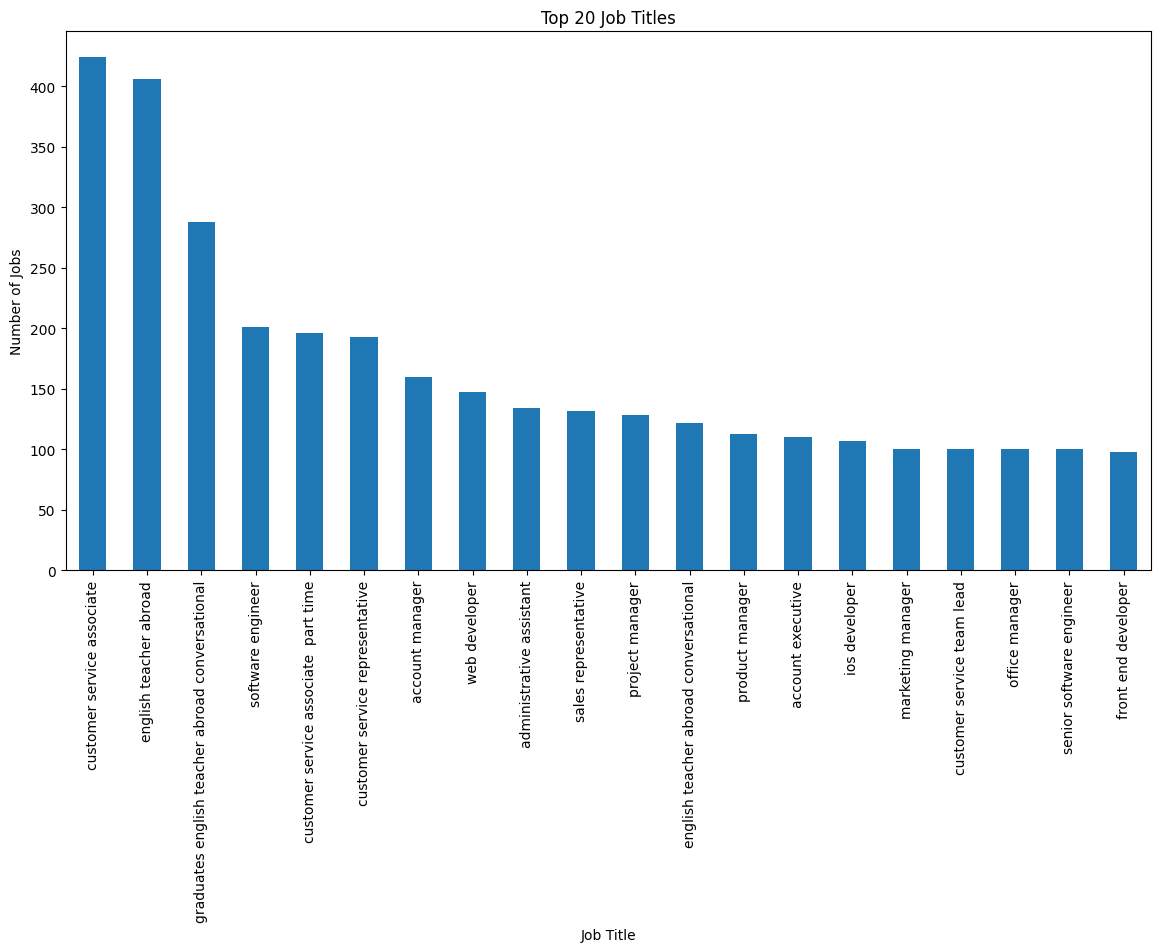

In [16]:
plt.figure(figsize=(14,7))

df["job_title"].value_counts().head(20).plot(kind="bar")

plt.title("Top 20 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=90)

plt.show()

In [17]:
df["text_length"] = df["text"].str.len()

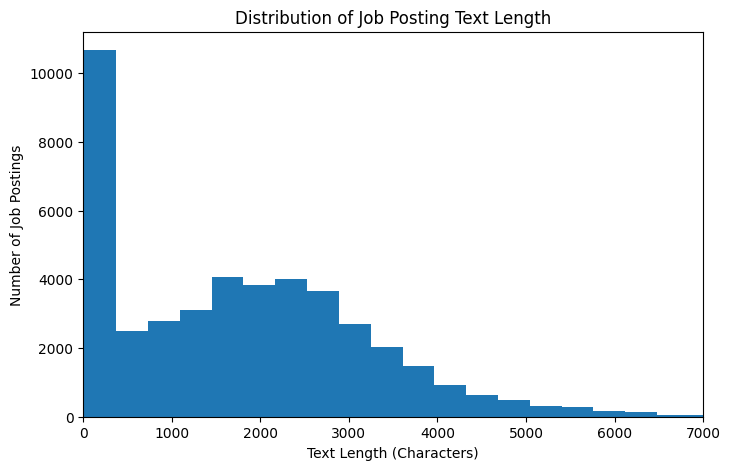

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["text_length"], bins=40)

plt.xlim(0, 7000)   # Adjust if needed

plt.title("Distribution of Job Posting Text Length")
plt.xlabel("Text Length (Characters)")
plt.ylabel("Number of Job Postings")

plt.show()

In [19]:
df["word_count"] = df["text"].str.split().str.len()

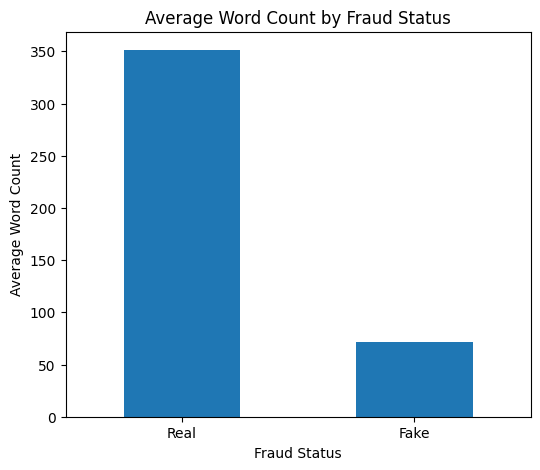

In [20]:
avg_words = df.groupby("fraudulent")["word_count"].mean()

plt.figure(figsize=(6,5))

avg_words.plot(kind="bar")

plt.title("Average Word Count by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Average Word Count")

plt.xticks([0,1], ["Real", "Fake"], rotation=0)

plt.show()

<Figure size 800x500 with 0 Axes>

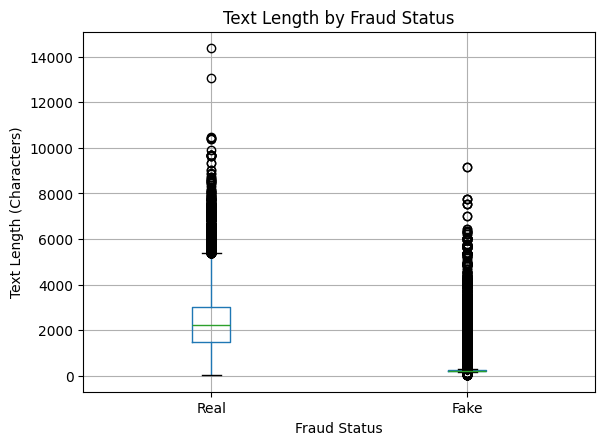

In [21]:
plt.figure(figsize=(8,5))

df.boxplot(column="text_length", by="fraudulent")

plt.title("Text Length by Fraud Status")
plt.suptitle("")

plt.xlabel("Fraud Status")
plt.ylabel("Text Length (Characters)")

plt.xticks([1,2], ["Real", "Fake"])

plt.show()

<Figure size 700x500 with 0 Axes>

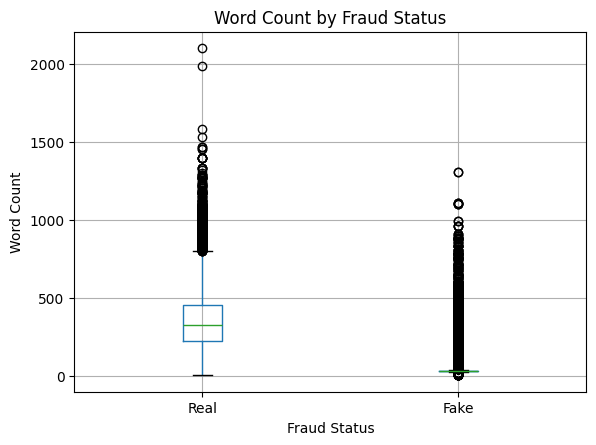

In [22]:
plt.figure(figsize=(7,5))

df.boxplot(column="word_count", by="fraudulent")

plt.title("Word Count by Fraud Status")
plt.suptitle("")

plt.xlabel("Fraud Status")
plt.ylabel("Word Count")

plt.xticks([1,2], ["Real", "Fake"])

plt.show()

In [23]:
real_jobs = df[df["fraudulent"] == 0]["text"]
fake_jobs = df[df["fraudulent"] == 1]["text"]
real_jobs = df[df["fraudulent"] == 0]["text"]
fake_jobs = df[df["fraudulent"] == 1]["text"]

[('experience', 58149), ('work', 54293), ('team', 52794), ('business', 36467), ('customer', 31815), ('company', 31663), ('new', 29979), ('skills', 28412), ('sales', 27248), ('management', 27139), ('development', 26720), ('services', 24838), ('service', 23988), ('working', 23465), ('years', 23371), ('marketing', 21819), ('looking', 21807), ('design', 20783), ('people', 19883), ('clients', 19766)]


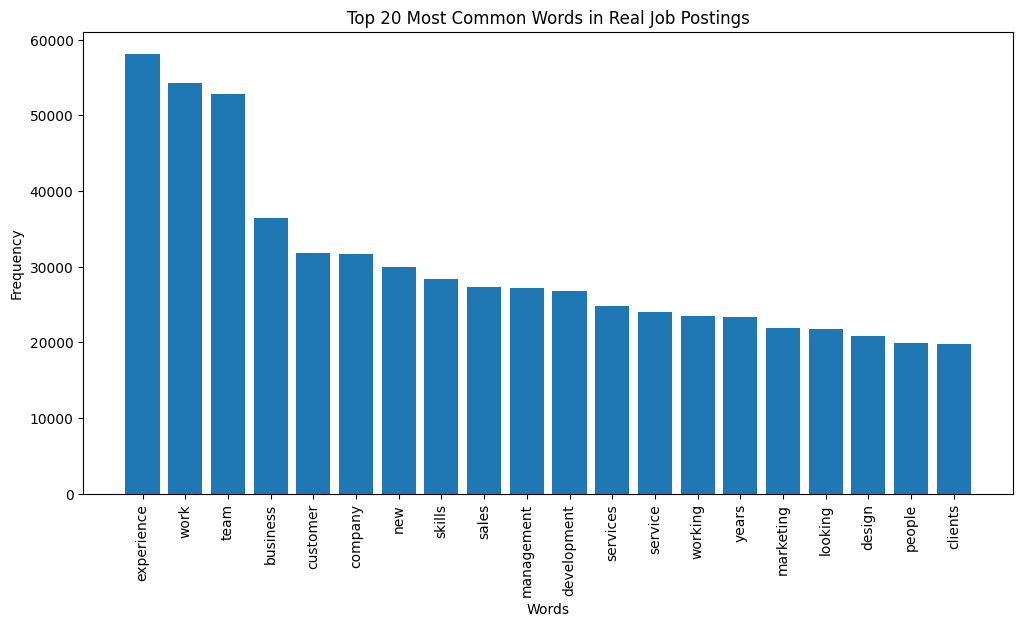

In [24]:
top_real = get_top_words(real_jobs)

print(top_real)
words = [word for word, count in top_real]
counts = [count for word, count in top_real]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.title("Top 20 Most Common Words in Real Job Postings")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.show()

[('knowledge', 11226), ('required', 11175), ('degree', 10777), ('earn', 10402), ('week', 10375), ('hours', 10374), ('hiring', 10371), ('basic', 10328), ('contact', 10306), ('flexible', 10206), ('established', 10196), ('immediate', 10116), ('work', 4053), ('experience', 3974), ('skills', 2825), ('amp', 2064), ('service', 2027), ('customer', 2004), ('team', 1983), ('business', 1953)]


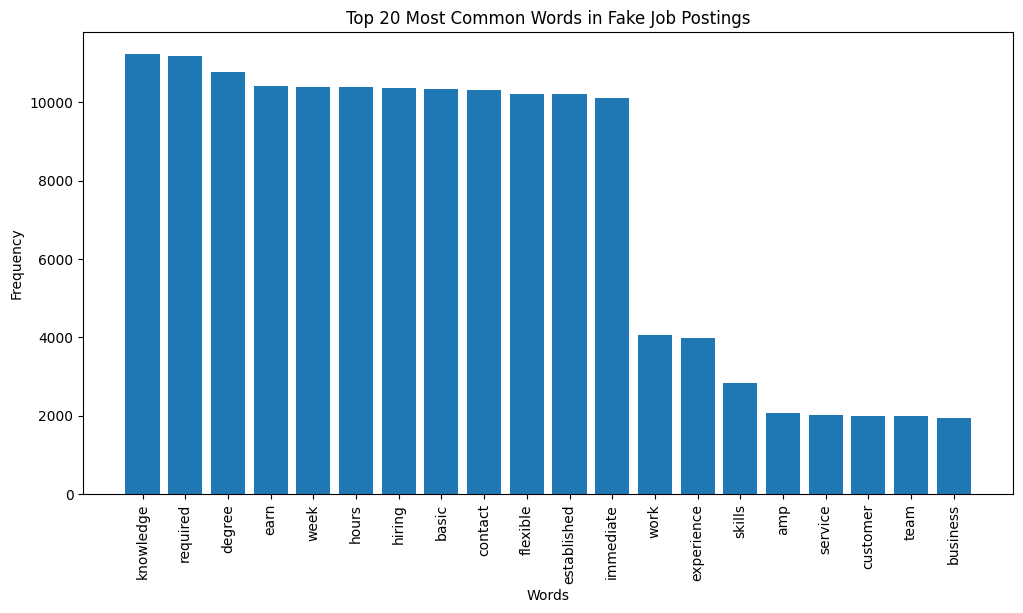

In [25]:
top_fake = get_top_words(fake_jobs)

print(top_fake)
words = [word for word, count in top_fake]
counts = [count for word, count in top_fake]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.title("Top 20 Most Common Words in Fake Job Postings")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.show()

In [26]:
from collections import Counter

real_counter = Counter(" ".join(real_jobs).split())
fake_counter = Counter(" ".join(fake_jobs).split())
fake_unique = {}

for word, count in fake_counter.items():
    diff = count - real_counter.get(word, 0)
    if diff > 0:
        fake_unique[word] = diff

[('earn', 9937), ('immediate', 9319), ('week', 8050), ('basic', 7625), ('hiring', 7353), ('flexible', 7074), ('contact', 6854), ('established', 6185), ('no', 6069), ('hours', 5103), ('now', 4433), ('degree', 682), ('sons', 530), ('plc', 529), ('hotmailcom', 438), ('yahoocom', 437), ('gmailcom', 395), ('surveyor', 342), ('officer', 318), ('aker', 317)]


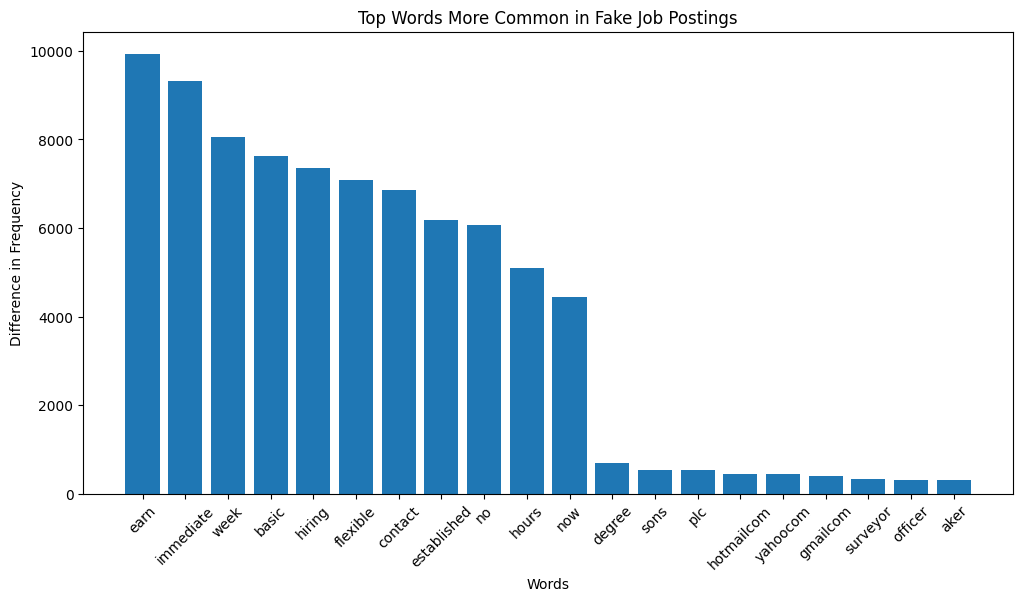

In [27]:
top_fake_unique = Counter(fake_unique).most_common(20)

print(top_fake_unique)
import matplotlib.pyplot as plt

words = [word for word, count in top_fake_unique]
counts = [count for word, count in top_fake_unique]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.title("Top Words More Common in Fake Job Postings")
plt.xlabel("Words")
plt.ylabel("Difference in Frequency")

plt.xticks(rotation=45)

plt.show()

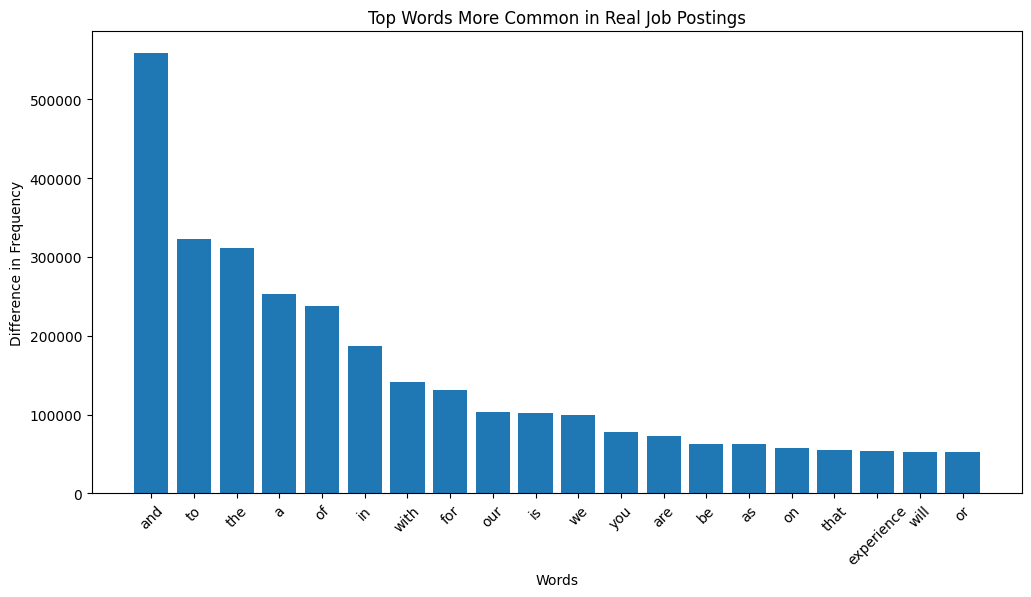

In [28]:
real_unique = {}

for word, count in real_counter.items():
    diff = count - fake_counter.get(word, 0)
    if diff > 0:
        real_unique[word] = diff

top_real_unique = Counter(real_unique).most_common(20)
words = [word for word, count in top_real_unique]
counts = [count for word, count in top_real_unique]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.title("Top Words More Common in Real Job Postings")
plt.xlabel("Words")
plt.ylabel("Difference in Frequency")

plt.xticks(rotation=45)

plt.show()

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

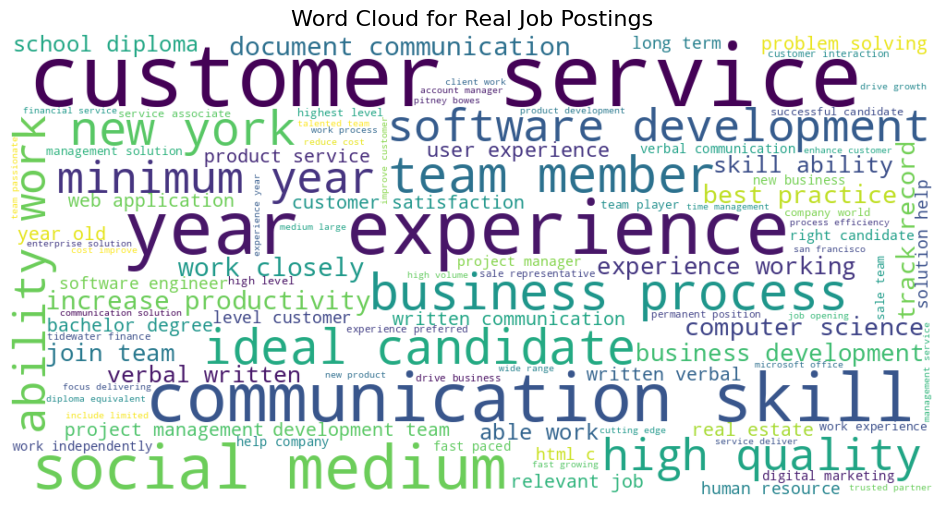

In [30]:
real_text = " ".join(df[df["fraudulent"] == 0]["clean_text"])

wordcloud_real = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(real_text)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud_real, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Real Job Postings", fontsize=16)
plt.show()

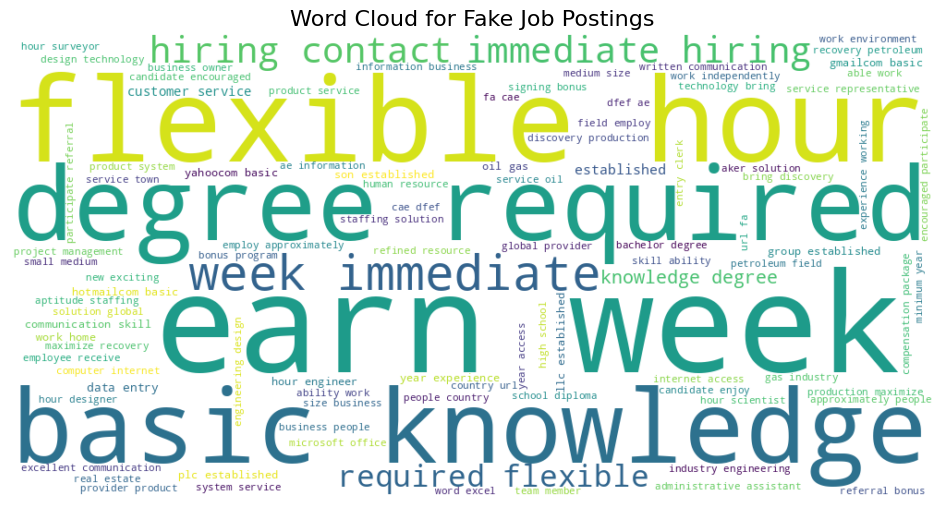

In [31]:
fake_text = " ".join(df[df["fraudulent"] == 1]["clean_text"])

wordcloud_fake = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(fake_text)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud_fake, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Fake Job Postings", fontsize=16)
plt.show()

In [32]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english",
    max_features=20
)

X_real = vectorizer.fit_transform(df[df["fraudulent"] == 0]["clean_text"])

real_bigram_counts = X_real.toarray().sum(axis=0)

real_bigrams = sorted(
    zip(vectorizer.get_feature_names_out(), real_bigram_counts),
    key=lambda x: x[1],
    reverse=True
)

real_bigrams

[('customer service', np.int64(11196)),
 ('year experience', np.int64(7976)),
 ('communication skill', np.int64(6525)),
 ('social medium', np.int64(5212)),
 ('business process', np.int64(3338)),
 ('team member', np.int64(3303)),
 ('ideal candidate', np.int64(3049)),
 ('new york', np.int64(2880)),
 ('software development', np.int64(2690)),
 ('high quality', np.int64(2613)),
 ('minimum year', np.int64(2582)),
 ('ability work', np.int64(2553)),
 ('increase productivity', np.int64(2537)),
 ('work closely', np.int64(2486)),
 ('document communication', np.int64(2484)),
 ('computer science', np.int64(2385)),
 ('track record', np.int64(2362)),
 ('best practice', np.int64(2356)),
 ('experience working', np.int64(2267)),
 ('business development', np.int64(2233))]

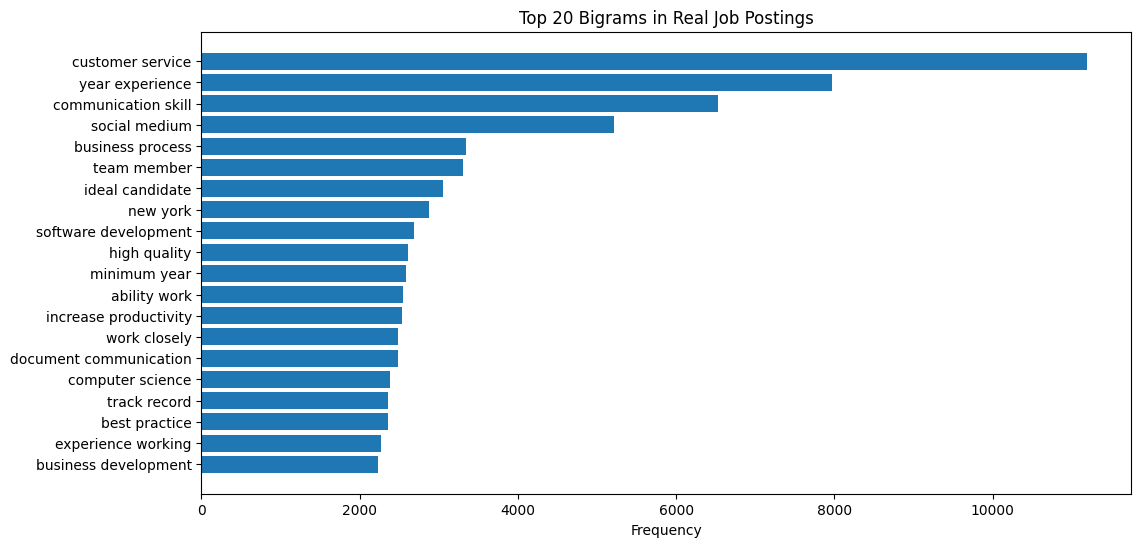

In [33]:
phrases = [x[0] for x in real_bigrams]
counts = [x[1] for x in real_bigrams]

plt.figure(figsize=(12,6))
plt.barh(phrases, counts)
plt.title("Top 20 Bigrams in Real Job Postings")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()

In [34]:
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english",
    max_features=20
)

X_fake = vectorizer.fit_transform(df[df["fraudulent"] == 1]["clean_text"])

fake_bigram_counts = X_fake.toarray().sum(axis=0)

fake_bigrams = sorted(
    zip(vectorizer.get_feature_names_out(), fake_bigram_counts),
    key=lambda x: x[1],
    reverse=True
)

fake_bigrams

[('earn week', np.int64(10072)),
 ('flexible hour', np.int64(10018)),
 ('basic knowledge', np.int64(10011)),
 ('degree required', np.int64(10008)),
 ('hiring contact', np.int64(10000)),
 ('immediate hiring', np.int64(10000)),
 ('required flexible', np.int64(10000)),
 ('week immediate', np.int64(10000)),
 ('knowledge degree', np.int64(2171)),
 ('customer service', np.int64(894)),
 ('data entry', np.int64(724)),
 ('plc established', np.int64(596)),
 ('llc established', np.int64(560)),
 ('son established', np.int64(553)),
 ('communication skill', np.int64(528)),
 ('group established', np.int64(524)),
 ('year experience', np.int64(484)),
 ('work home', np.int64(474)),
 ('hotmailcom basic', np.int64(438)),
 ('yahoocom basic', np.int64(437))]

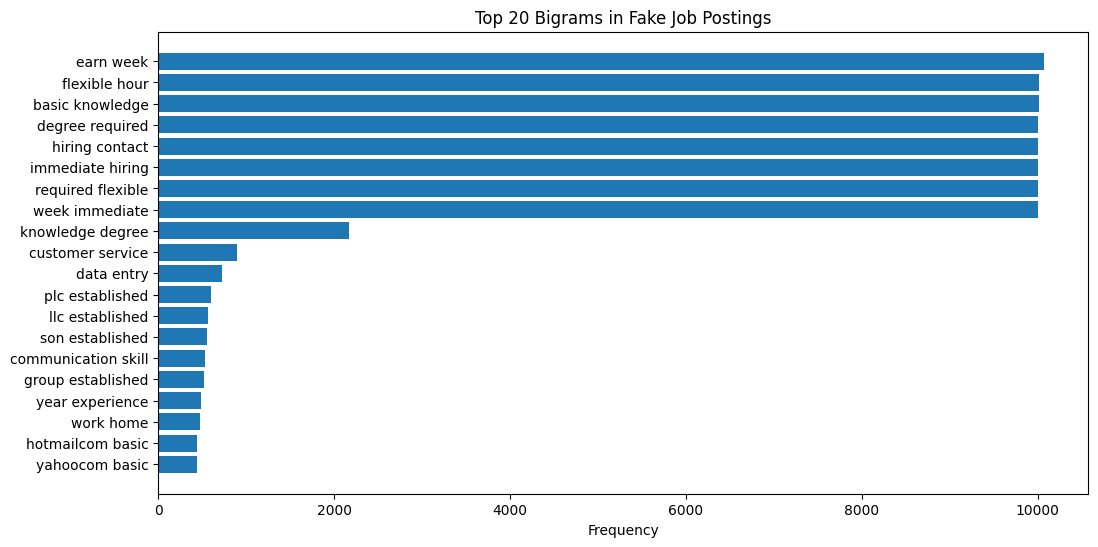

In [35]:
phrases = [x[0] for x in fake_bigrams]
counts = [x[1] for x in fake_bigrams]

plt.figure(figsize=(12,6))
plt.barh(phrases, counts)
plt.title("Top 20 Bigrams in Fake Job Postings")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()

In [36]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Create bigrams
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english",
    max_features=30
)

# Fit on all cleaned text
X = vectorizer.fit_transform(df["clean_text"])

# Create DataFrame
bigram_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

bigram_df["fraudulent"] = df["fraudulent"].values

# Sum frequencies
real_counts = bigram_df[bigram_df["fraudulent"] == 0].drop(columns="fraudulent").sum()
fake_counts = bigram_df[bigram_df["fraudulent"] == 1].drop(columns="fraudulent").sum()

# Select the 10 most frequent fake-job bigrams
top_fake = fake_counts.sort_values(ascending=False).head(10)

comparison = pd.DataFrame({
    "Fake": fake_counts[top_fake.index],
    "Real": real_counts[top_fake.index]
})

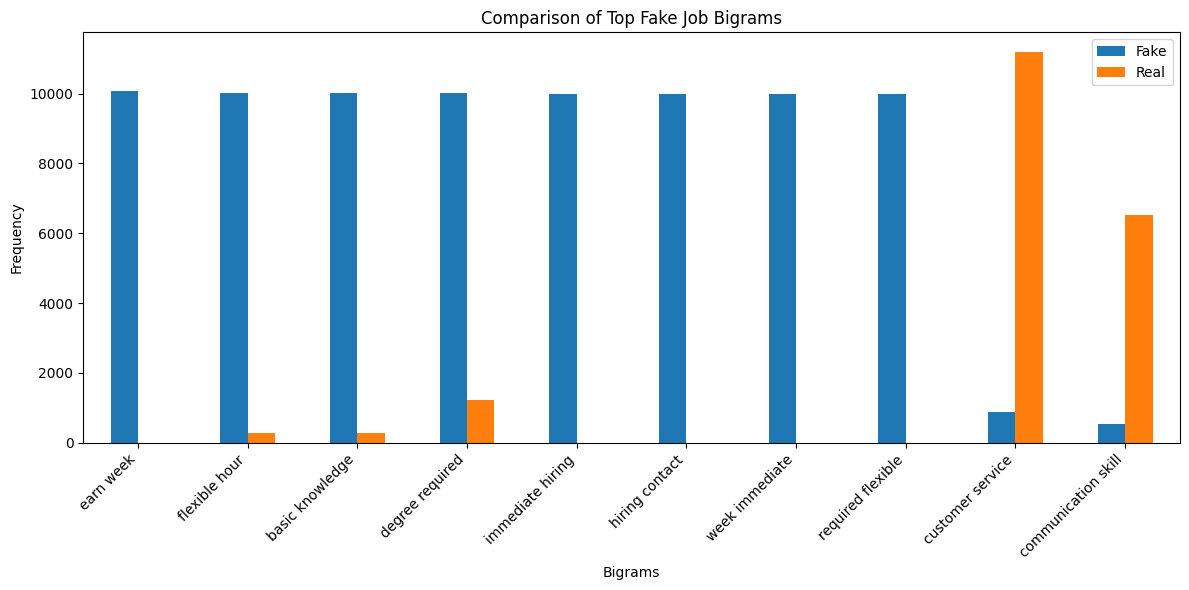

In [37]:
comparison.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Top Fake Job Bigrams")
plt.xlabel("Bigrams")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

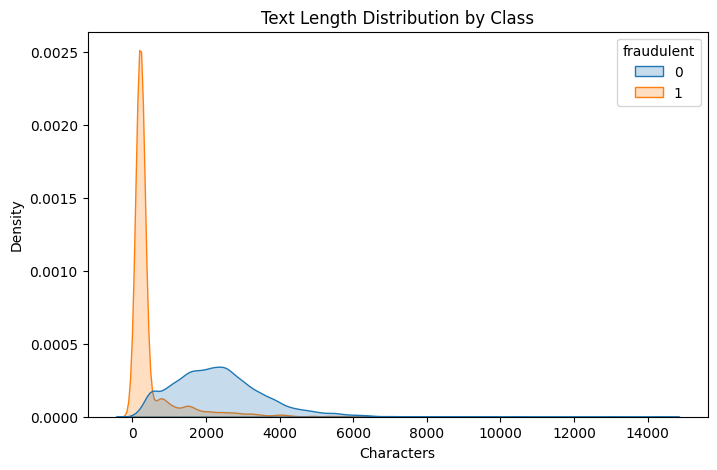

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="text_length",
    hue="fraudulent",
    fill=True,
    common_norm=False
)

plt.title("Text Length Distribution by Class")
plt.xlabel("Characters")
plt.show()

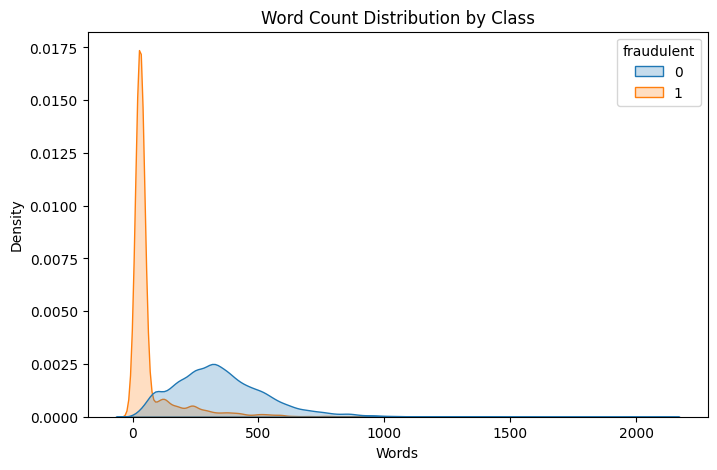

In [39]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="word_count",
    hue="fraudulent",
    fill=True,
    common_norm=False
)

plt.title("Word Count Distribution by Class")
plt.xlabel("Words")
plt.show()

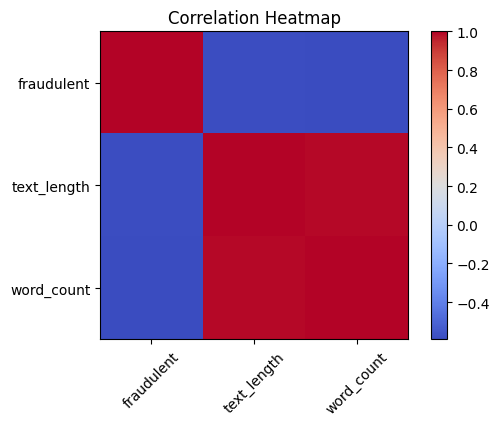

In [40]:
numeric_cols = [
    "fraudulent",
    "text_length",
    "word_count"
]

corr = df[numeric_cols].corr()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.imshow(corr, cmap="coolwarm")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

In [41]:
X = df_model["clean_text"]
y = df_model["fraudulent"]

print(X.head())
print(y.head())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

0    mental health nurse rivera son established arm...
1    conference centre manager davidson jones gomez...
2    engineer land allen established member discus ...
3    forestwoodland manager forbes established hous...
4    production designer theatretelevisionfilm jenn...
Name: clean_text, dtype: object
0    1
1    1
2    1
3    1
4    1
Name: fraudulent, dtype: int64
Training samples: 20802
Testing samples: 5201


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=5,
    max_df=0.90
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(20802, 5000)
(5201, 5000)


In [43]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['aa' 'ab' 'abc' 'abc supply' 'ability' 'ability adapt' 'ability build'
 'ability communicate' 'ability effectively' 'ability learn'
 'ability manage' 'ability multitask' 'ability prioritize'
 'ability required' 'ability work' 'able' 'able communicate'
 'able demonstrate' 'able multitask' 'able perform' 'able work' 'abroad'
 'absolutely' 'ac' 'academic' 'accelerate' 'accept' 'acceptable'
 'acceptance' 'access']


In [44]:
import pandas as pd

doc = pd.DataFrame({
    "Term": feature_names,
    "Weight": X_train_tfidf[0].toarray().flatten()
})

doc = doc[doc["Weight"] > 0]

doc.sort_values("Weight", ascending=False).head(20)

,Term,Weight
4320,support,0.378812
3522,providing,0.229739
4193,sql,0.205101
1027,customer,0.163622
4326,support service,0.149743
4639,unix,0.143583
4713,valued,0.140935
680,client base,0.138694
4434,technical skill,0.137580
4716,varied,0.137444


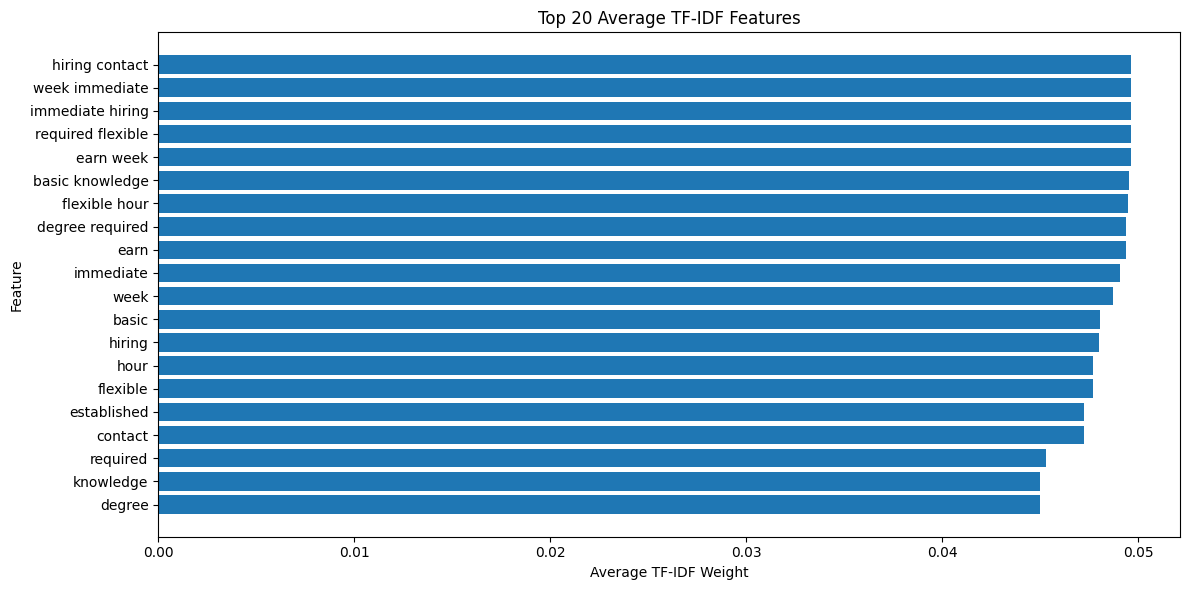

In [45]:
import numpy as np
import matplotlib.pyplot as plt

mean_scores = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

tfidf_df = pd.DataFrame({
    "Feature": feature_names,
    "Score": mean_scores
})

top20 = tfidf_df.sort_values(
    by="Score",
    ascending=False
).head(20)
plt.figure(figsize=(12,6))

plt.barh(top20["Feature"], top20["Score"])

plt.gca().invert_yaxis()

plt.title("Top 20 Average TF-IDF Features")
plt.xlabel("Average TF-IDF Weight")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [46]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train_tfidf, y_train)
y_pred = lr_model.predict(X_test_tfidf)
y_prob = lr_model.predict_proba(X_test_tfidf)[:,1]
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9769
Precision: 0.9980
Recall   : 0.9462
F1 Score : 0.9714


In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3045
           1       1.00      0.95      0.97      2156

    accuracy                           0.98      5201
   macro avg       0.98      0.97      0.98      5201
weighted avg       0.98      0.98      0.98      5201



[[3041    4]
 [ 116 2040]]


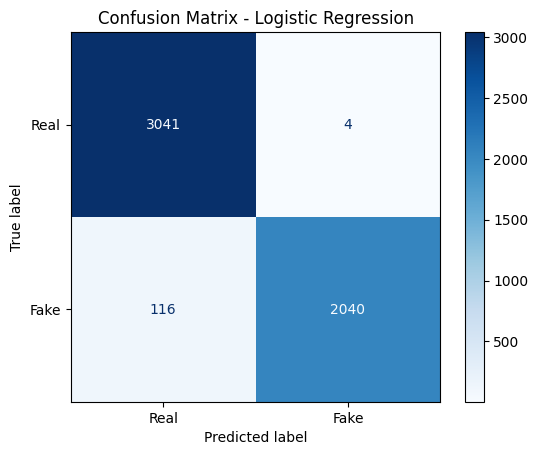

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real","Fake"]
).plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

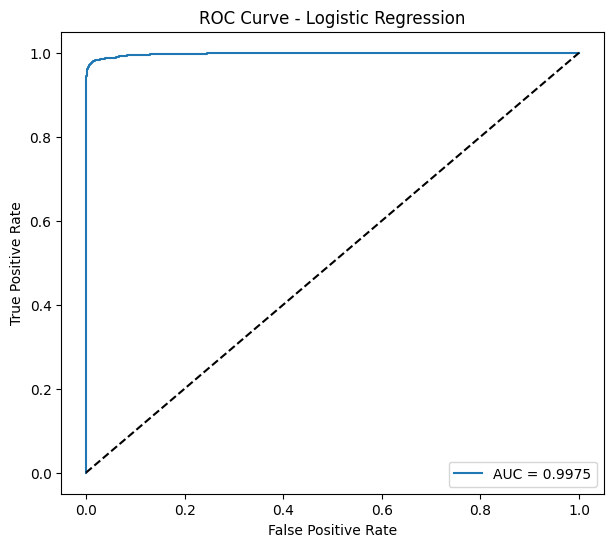

In [49]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

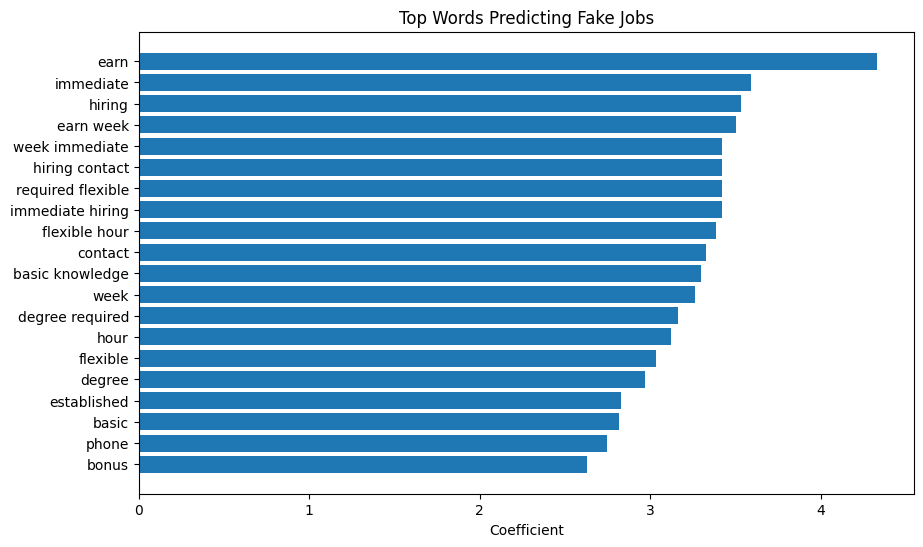

In [50]:
import pandas as pd

feature_names = tfidf.get_feature_names_out()

coefficients = lr_model.coef_[0]

importance = pd.DataFrame({
    "Word": feature_names,
    "Coefficient": coefficients
})

fake_words = importance.sort_values(
    by="Coefficient",
    ascending=False
)

fake_words.head(20)
top_fake = fake_words.head(20)

plt.figure(figsize=(10,6))

plt.barh(top_fake["Word"], top_fake["Coefficient"])

plt.gca().invert_yaxis()

plt.title("Top Words Predicting Fake Jobs")

plt.xlabel("Coefficient")

plt.show()

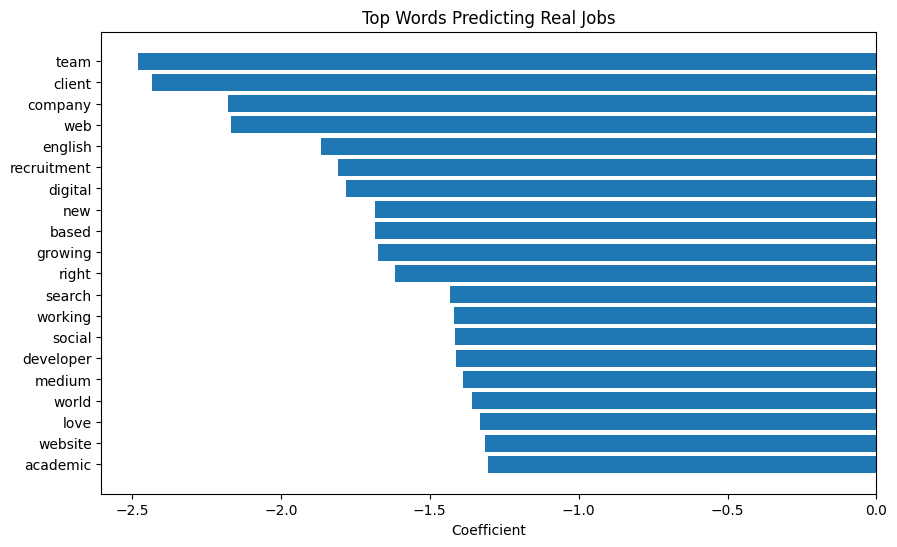

In [51]:
real_words = importance.sort_values(
    by="Coefficient"
)

real_words.head(20)
top_real = real_words.head(20)

plt.figure(figsize=(10,6))

plt.barh(top_real["Word"], top_real["Coefficient"])

plt.gca().invert_yaxis()

plt.title("Top Words Predicting Real Jobs")

plt.xlabel("Coefficient")

plt.show()

In [52]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

y_prob_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1 Score : {f1_nb:.4f}")
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

Accuracy : 0.9696
Precision: 0.9995
Recall   : 0.9272
F1 Score : 0.9620
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      3045
           1       1.00      0.93      0.96      2156

    accuracy                           0.97      5201
   macro avg       0.98      0.96      0.97      5201
weighted avg       0.97      0.97      0.97      5201



[[3044    1]
 [ 157 1999]]


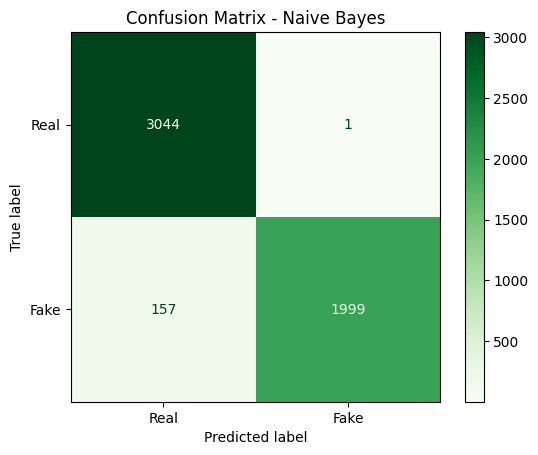

In [53]:
from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_test, y_pred_nb)

print(cm_nb)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Real", "Fake"]
).plot(cmap="Greens")

plt.title("Confusion Matrix - Naive Bayes")
plt.show()

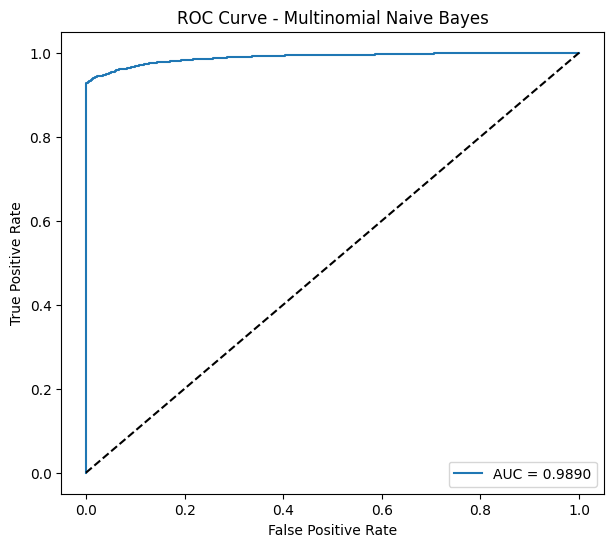

In [54]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.figure(figsize=(7,6))

plt.plot(fpr_nb, tpr_nb, label=f"AUC = {auc_nb:.4f}")

plt.plot([0,1],[0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Multinomial Naive Bayes")

plt.legend()

plt.show()

In [55]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        accuracy,
        accuracy_nb
    ],
    "Precision": [
        precision,
        precision_nb
    ],
    "Recall": [
        recall,
        recall_nb
    ],
    "F1 Score": [
        f1,
        f1_nb
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.976928,0.998043,0.946197,0.971429
1,Multinomial Naive Bayes,0.969621,0.999500,0.927180,0.961983


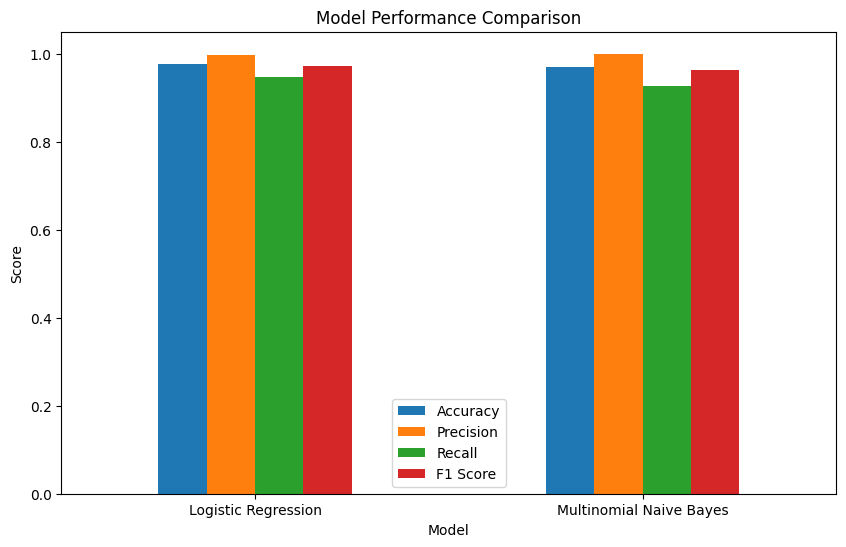

In [56]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.ylim(0, 1.05)

plt.show()

In [57]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

y_prob_rf = rf_model.predict_proba(X_test_tfidf)[:,1]

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9827
Precision: 0.9990
Recall   : 0.9592
F1 Score : 0.9787
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3045
           1       1.00      0.96      0.98      2156

    accuracy                           0.98      5201
   macro avg       0.99      0.98      0.98      5201
weighted avg       0.98      0.98      0.98      5201



[[3043    2]
 [  88 2068]]


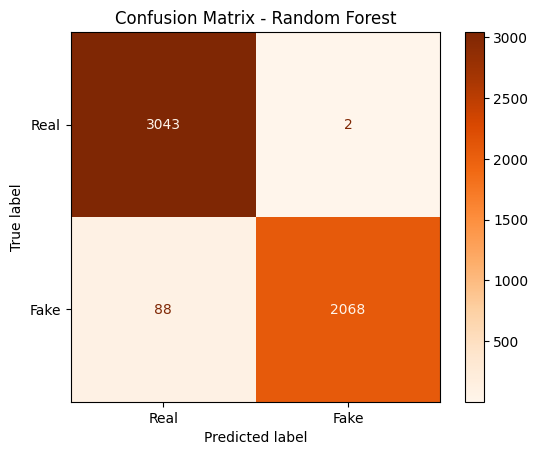

In [59]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Real", "Fake"]
).plot(cmap="Oranges")

plt.title("Confusion Matrix - Random Forest")

plt.show()

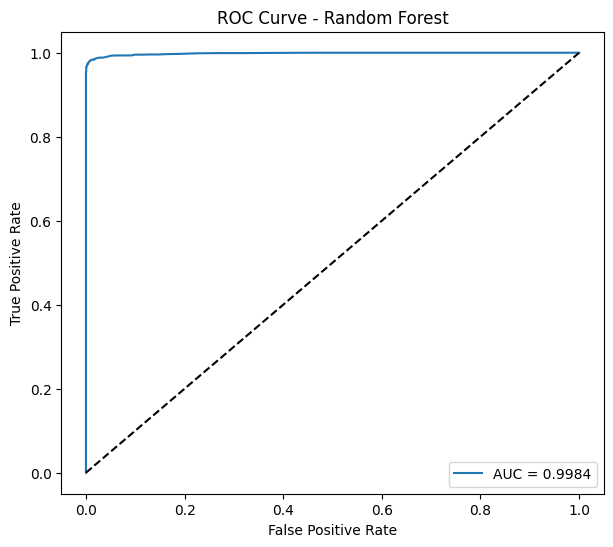

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7,6))

plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.4f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_nb,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_nb,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_nb,
        recall_rf
    ],
    "F1 Score": [
        f1,
        f1_nb,
        f1_rf
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.976928,0.998043,0.946197,0.971429
1,Multinomial Naive Bayes,0.969621,0.999500,0.927180,0.961983
2,Random Forest,0.982696,0.999034,0.959184,0.978703


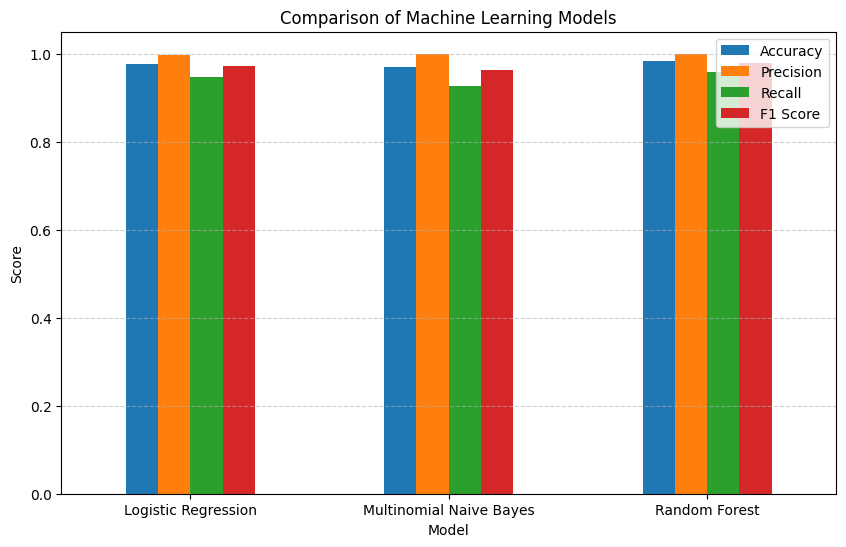

In [62]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [63]:
import pandas as pd

unlabelled_df = pd.read_excel(
    "/kaggle/input/datasets/adityammantri/trial-1/preprocessed_unlabelled_data_bert.xlsx"
)

In [64]:
print(unlabelled_df.head())

print(unlabelled_df.info())

print(unlabelled_df.isnull().sum())

                                               title           location  \
0                              marketing coordinator      princeton, nj   
1                  mental health therapist/counselor   fort collins, co   
2                        assitant restaurant manager     cincinnati, oh   
3  senior elder law / trusts and estates associat...  new hyde park, ny   
4                                 service technician     burlington, ia   

    salary_range         company_profile  \
0          20-17   corcoran sawyer smith   
1          50-30                     NaN   
2    65000-45000   the national exemplar   
3  175000-140000  abrams fensterman, llp   
4    80000-60000                     NaN   

                                            job_desc  \
0  job descriptiona leading real estate firm in n...   
1  at aspen therapy and wellness , we are committ...   
2  the national exemplar is accepting application...   
3  senior associate attorney - elder law / trusts...   
4  l

In [65]:
unlabelled_df["clean_text"] = (
    unlabelled_df["text_input"]
    .fillna("")
    .apply(preprocess_text)
)
unlabelled_df[["text_input", "clean_text"]].head()

,text_input,clean_text
0,"marketing coordinator | princeton, nj | 20-17 ...",marketing coordinator princeton nj corcoran sa...
1,mental health therapist/counselor | fort colli...,mental health therapist counselor fort collins...
2,"assitant restaurant manager | cincinnati, oh |...",assitant restaurant manager cincinnati oh nati...
3,senior elder law / trusts and estates associat...,senior elder law trust estate associate attorn...
4,"service technician | burlington, ia | 80000-60...",service technician burlington ia looking hvac ...


In [66]:
X_unlabelled_tfidf = tfidf.transform(unlabelled_df["clean_text"])

predictions = rf_model.predict(X_unlabelled_tfidf)

probabilities = rf_model.predict_proba(X_unlabelled_tfidf)[:, 1]
unlabelled_df["Predicted_Fraud"] = predictions
unlabelled_df["Fraud_Probability"] = probabilities
unlabelled_df[
    [
        "title",
        "location",
        "employment_type",
        "Predicted_Fraud",
        "Fraud_Probability"
    ]
].head(10)

,title,location,employment_type,Predicted_Fraud,Fraud_Probability
0,marketing coordinator,"princeton, nj",fulltime,0,0.025
1,mental health therapist/counselor,"fort collins, co",fulltime,0,0.015
2,assitant restaurant manager,"cincinnati, oh",fulltime,0,0.105
3,senior elder law / trusts and estates associat...,"new hyde park, ny",fulltime,0,0.005
4,service technician,"burlington, ia",fulltime,0,0.075
5,economic development and planning intern,"raleigh, nc",internship,0,0.020
6,producer,united states,contract,0,0.020
7,building engineer,"san francisco, ca",fulltime,0,0.035
8,respiratory therapist,"omaha, ne",fulltime,0,0.040
9,worship leader,"palm bay, fl",parttime,0,0.020


In [67]:
print(unlabelled_df["Predicted_Fraud"].value_counts())
(
    unlabelled_df["Predicted_Fraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Predicted_Fraud
0    126543
1         6
Name: count, dtype: int64


Predicted_Fraud
0    100.0
1      0.0
Name: proportion, dtype: float64

In [68]:
# Logistic Regression predictions
predictions_lr = lr_model.predict(X_unlabelled_tfidf)
probabilities_lr = lr_model.predict_proba(X_unlabelled_tfidf)[:, 1]

unlabelled_df["LR_Predicted_Fraud"] = predictions_lr
unlabelled_df["LR_Fraud_Probability"] = probabilities_lr

print(unlabelled_df["LR_Predicted_Fraud"].value_counts())

print(
    unlabelled_df["LR_Predicted_Fraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

LR_Predicted_Fraud
0    126384
1       165
Name: count, dtype: int64
LR_Predicted_Fraud
0    99.87
1     0.13
Name: proportion, dtype: float64


In [69]:
# Average probabilities
ensemble_prob = (probabilities + probabilities_lr) / 2

# Final ensemble prediction
ensemble_pred = (ensemble_prob >= 0.5).astype(int)

# Store in dataframe
unlabelled_df["Ensemble_Fraud_Probability"] = ensemble_prob
unlabelled_df["Ensemble_Predicted_Fraud"] = ensemble_pred

In [70]:
def risk_level(prob):
    if prob >= 0.80:
        return "High Risk"
    elif prob >= 0.50:
        return "Medium Risk"
    else:
        return "Low Risk"

unlabelled_df["Risk_Level"] = (
    unlabelled_df["Ensemble_Fraud_Probability"]
    .apply(risk_level)
)

In [71]:
# 1. Count ensemble predictions
print(unlabelled_df["Ensemble_Predicted_Fraud"].value_counts())

print(
    unlabelled_df["Ensemble_Predicted_Fraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Ensemble_Predicted_Fraud
0    126527
1        22
Name: count, dtype: int64
Ensemble_Predicted_Fraud
0    99.98
1     0.02
Name: proportion, dtype: float64


In [72]:
top_20 = (
    unlabelled_df
    .sort_values("Ensemble_Fraud_Probability", ascending=False)
    [["title", "location", "Ensemble_Fraud_Probability", "text_input"]]
    .head(20)
)

print(top_20)

                                      title                          location  \
98239              administrative assistant                       phoenix, az   
10293                oil and gas accountant                        denver, co   
89984        data entry clerk - phoenix, az                       phoenix, az   
174     administrative assistant bookkeeper  columbus, ohio metropolitan area   
39182   data entry/administrative assistant                     placentia, ca   
40837           manager, ent allergy clinic     gainesville metropolitan area   
17983                   dataentry part time                     united states   
64499                      data entry clerk                       fairfax, va   
125442                  data entry operator                           kolkata   
13971              administrative assistant                     united states   
17315                      data entry clerk                     united states   
98657     data entry special

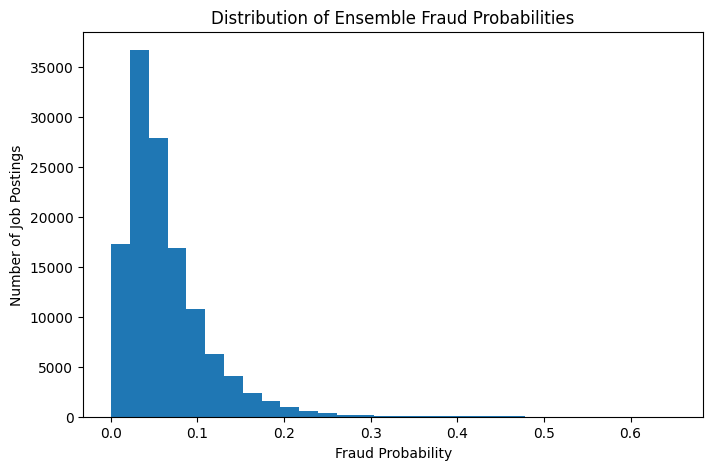

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(unlabelled_df["Ensemble_Fraud_Probability"], bins=30)

plt.title("Distribution of Ensemble Fraud Probabilities")
plt.xlabel("Fraud Probability")
plt.ylabel("Number of Job Postings")

plt.show()

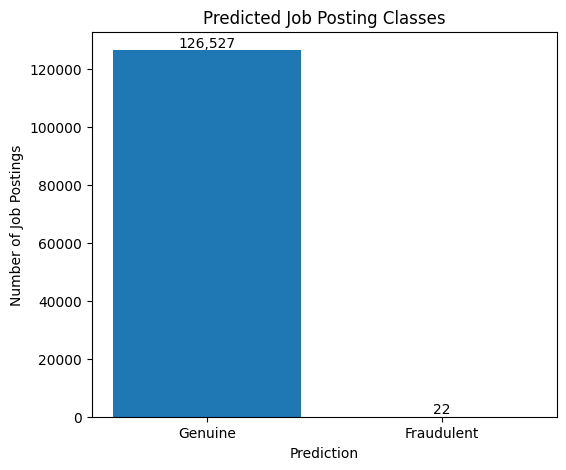

In [74]:
import matplotlib.pyplot as plt

counts = unlabelled_df["Ensemble_Predicted_Fraud"].value_counts().sort_index()

plt.figure(figsize=(6,5))
plt.bar(["Genuine", "Fraudulent"], counts.values)

plt.title("Predicted Job Posting Classes")
plt.xlabel("Prediction")
plt.ylabel("Number of Job Postings")

for i, value in enumerate(counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

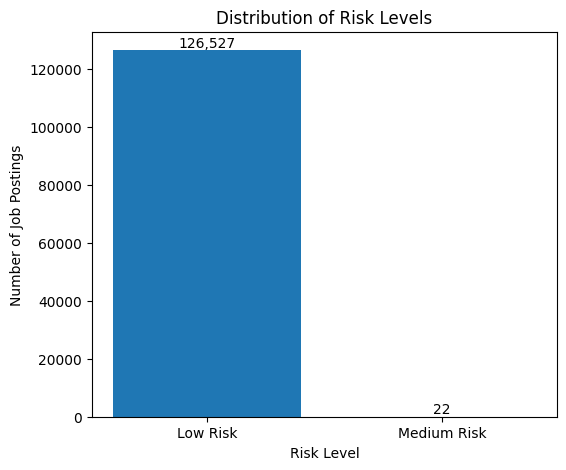

In [75]:
risk_counts = unlabelled_df["Risk_Level"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(risk_counts.index, risk_counts.values)

plt.title("Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Job Postings")

for i, value in enumerate(risk_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

In [76]:
def predict_job(job_text):
    job_clean = preprocess_text(job_text)

    job_tfidf = tfidf.transform([job_clean])

    rf_prob = rf_model.predict_proba(job_tfidf)[:,1][0]
    lr_prob = lr_model.predict_proba(job_tfidf)[:,1][0]

    ensemble_prob = (rf_prob + lr_prob)/2

    prediction = "Fraudulent" if ensemble_prob >= 0.5 else "Genuine"

    risk = risk_level(ensemble_prob)

    print("="*40)
    print("Prediction :", prediction)
    print("Fraud Probability :", round(ensemble_prob,3))
    print("Risk Level :", risk)
    print("="*40)

In [77]:
import joblib

joblib.dump(rf_model, "rf_model.joblib")
joblib.dump(lr_model, "lr_model.joblib")
joblib.dump(tfidf, "tfidf.joblib")

print("Models saved successfully!")

Models saved successfully!


In [78]:
import os

print(os.listdir("/kaggle/working"))

['rf_model.joblib', '__notebook__.ipynb', 'lr_model.joblib', 'tfidf.joblib']


In [79]:
predict_job("""
Administrative Assistant

Work from home

Immediate hiring

No degree required

Earn KES 50,000 weekly

Contact us via hiringteam@gmail.com
""")

Prediction : Fraudulent
Fraud Probability : 0.78
Risk Level : Medium Risk


In [80]:
predict_job("""
Software Engineer

Google Kenya

Bachelor's degree in Computer Science

5 years experience

Competitive salary

Apply through the official careers portal.
""")

Prediction : Genuine
Fraud Probability : 0.306
Risk Level : Low Risk


In [81]:
predict_job("""
Administrative Assistant

Work from home

No experience required

Earn KES 50,000 every week

Immediate hiring

Flexible hours

Send your CV to hiringteam@gmail.com
""")

Prediction : Fraudulent
Fraud Probability : 0.85
Risk Level : High Risk


In [82]:
predict_job("""
Software Engineer

Google Kenya

Location: Nairobi

Bachelor's degree in Computer Science

Three years of Python experience

Competitive salary

Apply through the official careers portal.
""")

Prediction : Genuine
Fraud Probability : 0.276
Risk Level : Low Risk


In [83]:
predict_job("""
Job Title: Customer Relations Officer

Organisation: Mount Kenya University

Location: Thika Campus, Kenya

Employment Type: Full-Time

Job Summary

Mount Kenya University is seeking a Customer Relations Officer to support the Open Distance and Electronic Learning (ODEL) Directorate. The successful candidate will ensure that customer inquiries are handled promptly and professionally while maintaining high standards of customer service.

Key Responsibilities

- Ensure that all calls to the ODEL Directorate are handled promptly.
- Respond to inquiries received through the ODEL email.
- Liaise with relevant university offices to resolve customer inquiries.
- Track customer issues and provide timely feedback.
- Prepare daily customer feedback reports.
- Maintain knowledge of university services to assist customers effectively.
- Advise customers on alternative communication methods where appropriate.

Requirements

- Excellent customer service and communication skills.
- Ability to multitask and manage time effectively.
- Strong interpersonal skills.
- Ability to work with different customer personalities.

Application Procedure

Interested candidates should apply through the official Mount Kenya University online recruitment portal before the stated deadline. Candidates should include their cover letter, indicate their salary expectations, and submit all required documents through the recruitment portal. Only shortlisted candidates will be contacted. Mount Kenya University is an equal opportunity employer and does not charge any fee during the recruitment process.
""")

Prediction : Genuine
Fraud Probability : 0.089
Risk Level : Low Risk
